# 02B. Dog Detection and Cropping YOLO Optimized — `proyecto_integrador_v2`

Este notebook es una versión optimizada del **Paso 02**.

## Objetivo

Regenerar los crops oficiales del pipeline usando la configuración que mejoró la re-identificación en el Paso 06:

```python
CONF_THRESHOLD = 0.15
CROP_MARGIN = 0.35
```

Esta configuración logró:

```text
crops_ok: 371 → 412
no_dog_detected: 157 → 116
Top-5 Same Dog Accuracy: 95.69% → 97.09%
```

## Por qué existe este Paso 02B

El Paso 02 original usaba:

```python
CONF_THRESHOLD = 0.25
CROP_MARGIN = 0.15
```

Eso funcionaba, pero dejaba fuera más imágenes.  
Este Paso 02B baja el umbral de detección y aumenta el margen del crop para conservar más cuerpo/contexto del perro.

## Estrategia de velocidad

Google Drive se usa para almacenamiento persistente, pero el procesamiento se hace en `/content` para acelerar:

```text
Google Drive = guardar resultados finales
/content = procesamiento rápido temporal
```

El notebook:

1. Carga el reporte del Paso 01.
2. Copia imágenes curadas a `/content`.
3. Corre YOLO desde disco local.
4. Guarda crops primero en `/content`.
5. Copia crops finales a Google Drive.
6. Guarda metadata e indicadores en Drive.

## Entradas

Requiere el reporte del Paso 01:

```text
curated_data/quality_reports/step01_image_quality_report.csv
```

Usa como imagen principal:

```text
curated_image_path
```

porque conserva mejor la estructura original de la imagen que `model_ready_224`.

## Salidas

Este notebook guarda los resultados optimizados en carpetas separadas para no sobrescribir el Paso 02 original:

```text
processed_data/dog_crops_optimized/
processed_data/metadata/step02b_detection_report_optimized.csv
reports/tables/step02b_detection_indicators_optimized.csv
reports/figures/step02b_detection_crop_samples_optimized.png
```

Después de correr este notebook, el Paso 03 debe usar:

```text
processed_data/metadata/step02b_detection_report_optimized.csv
```

y la columna:

```text
crop_path
```

para generar embeddings con los crops optimizados.

In [1]:
# 0. Instalación de dependencias

!pip install -q ultralytics opencv-python pillow pandas numpy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.5 MB/s eta 0:00:00


In [2]:

# 1. Imports y configuración general

from pathlib import Path
import json
import time
import math
import shutil
import subprocess
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from ultralytics import YOLO

pd.set_option("display.max_columns", 200)

SEED = 42
np.random.seed(SEED)

print("OpenCV:", cv2.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
OpenCV: 4.13.0


In [3]:
# 2. Montar Google Drive

from google.colab import drive

if Path("/content/drive/MyDrive").exists():
    print("Google Drive ya está montado.")
else:
    drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# 2B. Limpiar copias locales anteriores

# Esta limpieza NO borra los datos originales.
# Solo elimina carpetas temporales de /content y crops optimizados previos

CLEAN_LOCAL_CONTENT = True
CLEAN_PREVIOUS_OPTIMIZED_CROPS_DRIVE = True

if CLEAN_LOCAL_CONTENT:
    !rm -rf /content/proyecto_integrador_v2/images_curated_enhanced
    !rm -rf /content/proyecto_integrador_v2/dog_crops_optimized
    print("Copias locales anteriores eliminadas.")

print("Limpieza local lista.")

Copias locales anteriores eliminadas.
Limpieza local lista.


In [5]:
# 3. Rutas del proyecto y configuración optimizada


PROJECT_ROOT = Path("/content/drive/MyDrive/proyecto_integrador_v2")
CONFIG_PATH = PROJECT_ROOT / "project_config.json"

if CONFIG_PATH.exists():
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = json.load(f)
else:
    config = {}

CURATED_DATA_PATH = PROJECT_ROOT / "curated_data"
CURATED_IMAGES_PATH = CURATED_DATA_PATH / "images_curated"
DRIVE_ENHANCED_PATH = CURATED_IMAGES_PATH / "enhanced"

QUALITY_REPORTS_PATH = CURATED_DATA_PATH / "quality_reports"
STEP01_QUALITY_REPORT_PATH = QUALITY_REPORTS_PATH / "step01_image_quality_report.csv"

PROCESSED_DATA_PATH = PROJECT_ROOT / "processed_data"

# Salida optimizada separada del Paso 02 original
DOG_CROPS_OPTIMIZED_PATH = PROCESSED_DATA_PATH / "dog_crops_optimized"
METADATA_PATH = PROCESSED_DATA_PATH / "metadata"

REPORTS_PATH = PROJECT_ROOT / "reports"
FIGURES_PATH = REPORTS_PATH / "figures"
TABLES_PATH = REPORTS_PATH / "tables"

MODELS_PATH = PROJECT_ROOT / "models"
YOLO_MODELS_PATH = MODELS_PATH / "yolo"

for p in [
    DOG_CROPS_OPTIMIZED_PATH,
    METADATA_PATH,
    REPORTS_PATH,
    FIGURES_PATH,
    TABLES_PATH,
    YOLO_MODELS_PATH
]:
    p.mkdir(parents=True, exist_ok=True)

if CLEAN_PREVIOUS_OPTIMIZED_CROPS_DRIVE and DOG_CROPS_OPTIMIZED_PATH.exists():
    shutil.rmtree(DOG_CROPS_OPTIMIZED_PATH)
    DOG_CROPS_OPTIMIZED_PATH.mkdir(parents=True, exist_ok=True)
    print("Crops optimizados anteriores en Drive eliminados:", DOG_CROPS_OPTIMIZED_PATH)

detector_config = config.get("detector", {})

YOLO_MODEL_NAME = detector_config.get("default_model", "yolo26s.pt")
FALLBACK_YOLO_MODEL_NAME = detector_config.get("fallback_model", "yolo11s.pt")

# Configuración ganadora provisional del Paso 06
CONF_THRESHOLD = 0.15
CROP_MARGIN = 0.35

LOCAL_PROJECT_PATH = Path("/content/proyecto_integrador_v2")
LOCAL_ENHANCED_PATH = LOCAL_PROJECT_PATH / "images_curated_enhanced"
LOCAL_CROPS_OPTIMIZED_PATH = LOCAL_PROJECT_PATH / "dog_crops_optimized"

LOCAL_PROJECT_PATH.mkdir(parents=True, exist_ok=True)
LOCAL_CROPS_OPTIMIZED_PATH.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STEP01_QUALITY_REPORT_PATH:", STEP01_QUALITY_REPORT_PATH)
print("DRIVE_ENHANCED_PATH:", DRIVE_ENHANCED_PATH)
print("LOCAL_ENHANCED_PATH:", LOCAL_ENHANCED_PATH)
print("DOG_CROPS_OPTIMIZED_PATH:", DOG_CROPS_OPTIMIZED_PATH)
print("LOCAL_CROPS_OPTIMIZED_PATH:", LOCAL_CROPS_OPTIMIZED_PATH)
print("YOLO_MODEL_NAME:", YOLO_MODEL_NAME)
print("FALLBACK_YOLO_MODEL_NAME:", FALLBACK_YOLO_MODEL_NAME)
print("CONF_THRESHOLD:", CONF_THRESHOLD)
print("CROP_MARGIN:", CROP_MARGIN)

Crops optimizados anteriores en Drive eliminados: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/dog_crops_optimized
PROJECT_ROOT: /content/drive/MyDrive/proyecto_integrador_v2
STEP01_QUALITY_REPORT_PATH: /content/drive/MyDrive/proyecto_integrador_v2/curated_data/quality_reports/step01_image_quality_report.csv
DRIVE_ENHANCED_PATH: /content/drive/MyDrive/proyecto_integrador_v2/curated_data/images_curated/enhanced
LOCAL_ENHANCED_PATH: /content/proyecto_integrador_v2/images_curated_enhanced
DOG_CROPS_OPTIMIZED_PATH: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/dog_crops_optimized
LOCAL_CROPS_OPTIMIZED_PATH: /content/proyecto_integrador_v2/dog_crops_optimized
YOLO_MODEL_NAME: yolo26s.pt
FALLBACK_YOLO_MODEL_NAME: yolo11s.pt
CONF_THRESHOLD: 0.15
CROP_MARGIN: 0.35


In [6]:
# 4. Cargar reporte del Paso 01

if not STEP01_QUALITY_REPORT_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {STEP01_QUALITY_REPORT_PATH}. "
        "Ejecuta primero el Paso 01."
    )

quality_df = pd.read_csv(STEP01_QUALITY_REPORT_PATH)

print("Registros cargados del Paso 01:", len(quality_df))
print("Columnas:")
print(quality_df.columns.tolist())

display(quality_df.head())

Registros cargados del Paso 01: 20580
Columnas:
['image_path', 'relative_path', 'source_type', 'dog_id', 'report_id', 'filename', 'extension', 'read_status', 'read_error', 'curated_image_path', 'model_ready_image_path', 'width', 'height', 'aspect_ratio', 'brightness_mean', 'contrast_std', 'sharpness_laplacian_var', 'saturation_mean', 'colorfulness', 'edge_density', 'quality_label', 'quality_flags']


,image_path,relative_path,source_type,dog_id,report_id,filename,extension,read_status,read_error,curated_image_path,model_ready_image_path,width,height,aspect_ratio,brightness_mean,contrast_std,sharpness_laplacian_var,saturation_mean,colorfulness,edge_density,quality_label,quality_flags
0,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10074.jpg,base_images,NaN,NaN,n02085620_10074.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,333,500,0.666000,80.933724,67.169699,782.019819,70.510204,26.020002,0.086222,good,none
1,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10131.jpg,base_images,NaN,NaN,n02085620_10131.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,395,495,0.797980,57.823199,65.480311,361.080245,153.008863,50.975990,0.117330,good,none
2,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10621.jpg,base_images,NaN,NaN,n02085620_10621.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,500,298,1.677852,140.799376,39.013514,99.042644,45.400081,24.762783,0.027584,acceptable,low_sharpness
3,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_1073.jpg,base_images,NaN,NaN,n02085620_1073.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,345,500,0.690000,113.087635,77.667901,1297.671480,76.206643,24.119247,0.137217,good,none
4,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10976.jpg,base_images,NaN,NaN,n02085620_10976.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,322,484,0.665289,121.949656,38.751610,277.332779,118.489746,35.805992,0.048387,good,none


In [7]:
# 5. Preparar dataframe de detección

required_cols = ["image_path", "curated_image_path", "read_status", "quality_label"]
missing = [c for c in required_cols if c not in quality_df.columns]

if missing:
    raise ValueError(f"Faltan columnas necesarias del Paso 01: {missing}")

detection_input_df = quality_df[
    quality_df["read_status"] == "ok"
].copy().reset_index(drop=True)

detection_input_df["detection_input_path"] = detection_input_df["curated_image_path"]

missing_curated = detection_input_df["detection_input_path"].isna() | (
    detection_input_df["detection_input_path"].astype(str).str.len() == 0
)

detection_input_df.loc[missing_curated, "detection_input_path"] = detection_input_df.loc[
    missing_curated, "image_path"
]

detection_input_df["detection_input_exists_drive"] = detection_input_df["detection_input_path"].apply(
    lambda p: Path(str(p)).exists()
)

print("Imágenes listas para detección:", len(detection_input_df))
print("Existencia en Drive:")
print(detection_input_df["detection_input_exists_drive"].value_counts(dropna=False))

detection_input_df = (
    detection_input_df[detection_input_df["detection_input_exists_drive"]]
    .drop(columns=["detection_input_exists_drive"])
    .reset_index(drop=True)
)

print("Imágenes válidas para YOLO:", len(detection_input_df))
display(detection_input_df[["source_type", "quality_label", "detection_input_path"]].head())

Imágenes listas para detección: 20580
Existencia en Drive:
detection_input_exists_drive
True    20580
Name: count, dtype: int64
Imágenes válidas para YOLO: 20580


,source_type,quality_label,detection_input_path
0,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...
1,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...
2,base_images,acceptable,/content/drive/MyDrive/proyecto_integrador_v2/...
3,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...
4,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...


In [8]:
# 5B. Optimización: copiar imágenes curadas a /content

if not DRIVE_ENHANCED_PATH.exists():
    raise FileNotFoundError(f"No existe la carpeta de imágenes curadas: {DRIVE_ENHANCED_PATH}")

print("Copiando imágenes curadas a /content...")
start_copy = time.time()

subprocess.run(
    ["cp", "-r", str(DRIVE_ENHANCED_PATH), str(LOCAL_ENHANCED_PATH)],
    check=True
)

elapsed_copy = (time.time() - start_copy) / 60
print("Copia terminada. Tiempo:", round(elapsed_copy, 2), "minutos")

detection_input_df["original_detection_input_path"] = detection_input_df["detection_input_path"]

detection_input_df["detection_input_path"] = detection_input_df["detection_input_path"].astype(str).str.replace(
    str(DRIVE_ENHANCED_PATH),
    str(LOCAL_ENHANCED_PATH),
    regex=False
)

detection_input_df["detection_input_exists_local"] = detection_input_df["detection_input_path"].apply(
    lambda p: Path(str(p)).exists()
)

print("Existencia local:")
print(detection_input_df["detection_input_exists_local"].value_counts(dropna=False))

detection_input_df = (
    detection_input_df[detection_input_df["detection_input_exists_local"]]
    .drop(columns=["detection_input_exists_local"])
    .reset_index(drop=True)
)

print("Imágenes listas para YOLO desde /content:", len(detection_input_df))
display(detection_input_df[["detection_input_path", "quality_label"]].head())

Copiando imágenes curadas a /content...
Copia terminada. Tiempo: 5.41 minutos
Existencia local:
detection_input_exists_local
True    20580
Name: count, dtype: int64
Imágenes listas para YOLO desde /content: 20580


,detection_input_path,quality_label
0,/content/proyecto_integrador_v2/images_curated...,good
1,/content/proyecto_integrador_v2/images_curated...,good
2,/content/proyecto_integrador_v2/images_curated...,acceptable
3,/content/proyecto_integrador_v2/images_curated...,good
4,/content/proyecto_integrador_v2/images_curated...,good


In [9]:
# 6. Cargar modelo YOLO

def load_yolo_detector(primary_model: str, fallback_model: str):
    """Carga YOLO. Si el modelo principal falla, usa fallback."""
    try:
        print(f"Intentando cargar detector principal: {primary_model}")
        model = YOLO(primary_model)
        selected_model = primary_model
    except Exception as e:
        print("No se pudo cargar el detector principal.")
        print("Error:", e)
        print(f"Usando detector fallback: {fallback_model}")
        model = YOLO(fallback_model)
        selected_model = fallback_model

    return model, selected_model


yolo_detector, selected_yolo_model = load_yolo_detector(
    YOLO_MODEL_NAME,
    FALLBACK_YOLO_MODEL_NAME
)

dog_class_id = None

for class_id, class_name in yolo_detector.names.items():
    if str(class_name).lower() == "dog":
        dog_class_id = int(class_id)
        break

if dog_class_id is None:
    raise ValueError("No se encontró la clase 'dog' en el modelo YOLO seleccionado.")

print("Modelo YOLO seleccionado:", selected_yolo_model)
print("ID clase dog:", dog_class_id)
print("Clases disponibles:", yolo_detector.names)

Intentando cargar detector principal: yolo26s.pt
Modelo YOLO seleccionado: yolo26s.pt
ID clase dog: 16
Clases disponibles: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'di

In [10]:
# 7. Funciones de detección y crop

def detect_dogs_yolo(image_path, model, dog_class_id, conf_threshold=0.15):
    """Detecta perros en una imagen usando YOLO."""
    results = model(str(image_path), conf=conf_threshold, verbose=False)

    detections = []

    for result in results:
        boxes = result.boxes

        if boxes is None:
            continue

        for box in boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])

            if class_id == dog_class_id:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

                w = max(0, x2 - x1)
                h = max(0, y2 - y1)
                area = int(w * h)

                detections.append({
                    "class_id": class_id,
                    "class_name": "dog",
                    "confidence": confidence,
                    "x1": int(x1),
                    "y1": int(y1),
                    "x2": int(x2),
                    "y2": int(y2),
                    "box_width": int(w),
                    "box_height": int(h),
                    "area": area
                })

    return detections


def select_best_detection(detections):
    """Selecciona la detección principal usando área y confianza."""
    if len(detections) == 0:
        return None

    return sorted(
        detections,
        key=lambda d: (d["area"], d["confidence"]),
        reverse=True
    )[0]


def crop_detection(image_path, detection, output_path, margin=0.35):
    """Genera crop con margen alrededor de la detección."""
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        return None, "image_not_readable"

    img_h, img_w = image_bgr.shape[:2]

    x1, y1, x2, y2 = detection["x1"], detection["y1"], detection["x2"], detection["y2"]

    box_w = x2 - x1
    box_h = y2 - y1

    mx = int(box_w * margin)
    my = int(box_h * margin)

    x1m = max(0, x1 - mx)
    y1m = max(0, y1 - my)
    x2m = min(img_w, x2 + mx)
    y2m = min(img_h, y2 + my)

    if x2m <= x1m or y2m <= y1m:
        return None, "invalid_crop_coordinates"

    crop = image_bgr[y1m:y2m, x1m:x2m]

    output_path.parent.mkdir(parents=True, exist_ok=True)

    ok = cv2.imwrite(str(output_path), crop)

    if not ok:
        return None, "crop_write_failed"

    crop_h, crop_w = crop.shape[:2]

    crop_info = {
        "crop_path": str(output_path),
        "crop_width": int(crop_w),
        "crop_height": int(crop_h),
        "crop_x1": int(x1m),
        "crop_y1": int(y1m),
        "crop_x2": int(x2m),
        "crop_y2": int(y2m)
    }

    return crop_info, None


def build_crop_output_path(row, input_path):
    """Construye ruta local de salida para crop conservando estructura relativa."""
    source_type = row.get("source_type", "unknown")
    relative_path = row.get("relative_path", None)

    if pd.isna(relative_path) or relative_path is None:
        input_path = Path(input_path)
        relative_path = Path(source_type) / input_path.name
    else:
        relative_path = Path(str(relative_path))

    output_path = LOCAL_CROPS_OPTIMIZED_PATH / source_type / relative_path
    output_path = output_path.with_suffix(".jpg")

    return output_path

## Ejecución optimizada

Este paso usa:

```python
CONF_THRESHOLD = 0.15
CROP_MARGIN = 0.35
```

El objetivo es aumentar la cobertura de detección y conservar más información corporal del perro sin degradar la calidad de los embeddings.

In [11]:
# 8. Ejecutar detección y generación de crops con checkpoint

CHECKPOINT_EVERY = 500
CHECKPOINT_PATH = METADATA_PATH / "step02b_detection_report_optimized_checkpoint.csv"

detection_records = []
processed_paths = set()

if CHECKPOINT_PATH.exists():
    checkpoint_df = pd.read_csv(CHECKPOINT_PATH)

    USE_CHECKPOINT = False

    if USE_CHECKPOINT:
        detection_records = checkpoint_df.to_dict("records")
        processed_paths = set(checkpoint_df["detection_input_path"].astype(str).tolist())
        print("Checkpoint cargado:", len(detection_records), "registros")
    else:
        CHECKPOINT_PATH.unlink()
        print("Checkpoint anterior eliminado.")
else:
    print("No hay checkpoint previo. Iniciando desde cero.")

pending_df = detection_input_df[
    ~detection_input_df["detection_input_path"].astype(str).isin(processed_paths)
].copy()

print("Pendientes por procesar:", len(pending_df))

start = time.time()

for _, row in tqdm(pending_df.iterrows(), total=len(pending_df)):
    input_path = Path(row["detection_input_path"])

    base_record = row.to_dict()
    base_record.update({
        "pipeline_step": "02B_optimized",
        "selected_yolo_model": selected_yolo_model,
        "conf_threshold": CONF_THRESHOLD,
        "crop_margin": CROP_MARGIN,
        "dog_detected": False,
        "num_dog_detections": 0,
        "best_confidence": np.nan,
        "best_area": np.nan,
        "best_x1": np.nan,
        "best_y1": np.nan,
        "best_x2": np.nan,
        "best_y2": np.nan,
        "crop_status": "not_created",
        "crop_error": None,
        "crop_path": None,
        "crop_width": np.nan,
        "crop_height": np.nan,
        "needs_review_detection": False,
        "detection_review_reason": "none"
    })

    try:
        detections = detect_dogs_yolo(
            input_path,
            yolo_detector,
            dog_class_id,
            conf_threshold=CONF_THRESHOLD
        )

        base_record["num_dog_detections"] = len(detections)

        best_detection = select_best_detection(detections)

        if best_detection is None:
            base_record["dog_detected"] = False
            base_record["crop_status"] = "no_dog_detected"
            base_record["needs_review_detection"] = True
            base_record["detection_review_reason"] = "no_dog_detected"
            detection_records.append(base_record)
        else:
            base_record["dog_detected"] = True
            base_record["best_confidence"] = best_detection["confidence"]
            base_record["best_area"] = best_detection["area"]
            base_record["best_x1"] = best_detection["x1"]
            base_record["best_y1"] = best_detection["y1"]
            base_record["best_x2"] = best_detection["x2"]
            base_record["best_y2"] = best_detection["y2"]

            if len(detections) > 1:
                base_record["needs_review_detection"] = True
                base_record["detection_review_reason"] = "multiple_dogs_detected"

            crop_output_path = build_crop_output_path(row, input_path)

            crop_info, crop_error = crop_detection(
                input_path,
                best_detection,
                crop_output_path,
                margin=CROP_MARGIN
            )

            if crop_error is not None:
                base_record["crop_status"] = "error"
                base_record["crop_error"] = crop_error
                base_record["needs_review_detection"] = True

                if base_record["detection_review_reason"] == "none":
                    base_record["detection_review_reason"] = crop_error
            else:
                base_record["crop_status"] = "ok"
                base_record.update(crop_info)

            detection_records.append(base_record)

    except Exception as e:
        base_record["crop_status"] = "error"
        base_record["crop_error"] = str(e)
        base_record["needs_review_detection"] = True
        base_record["detection_review_reason"] = "exception"
        detection_records.append(base_record)

    if len(detection_records) % CHECKPOINT_EVERY == 0:
        pd.DataFrame(detection_records).to_csv(CHECKPOINT_PATH, index=False)
        print("Checkpoint guardado:", len(detection_records))

detection_df = pd.DataFrame(detection_records)
detection_df.to_csv(CHECKPOINT_PATH, index=False)

elapsed = (time.time() - start) / 60

print("Detección terminada.")
print("Tiempo:", round(elapsed, 2), "minutos")
print("Registros:", len(detection_df))

print("Dog detected:")
print(detection_df["dog_detected"].value_counts(dropna=False))

print("Crop status:")
print(detection_df["crop_status"].value_counts(dropna=False))

display(detection_df.head())

No hay checkpoint previo. Iniciando desde cero.
Pendientes por procesar: 20580


  2%|▏         | 500/20580 [03:51<2:18:40,  2.41it/s]

Checkpoint guardado: 500


  5%|▍         | 1000/20580 [07:29<2:02:45,  2.66it/s]

Checkpoint guardado: 1000


...

100%|█████████▉| 20500/20580 [2:30:40<01:16,  1.05it/s]

Checkpoint guardado: 20500


100%|██████████| 20580/20580 [2:31:14<00:00,  2.27it/s]


Detección terminada.
Tiempo: 151.26 minutos
Registros: 20580
Dog detected:
dog_detected
True     19568
False     1012
Name: count, dtype: int64
Crop status:
crop_status
ok                 19568
no_dog_detected     1012
Name: count, dtype: int64


,image_path,relative_path,source_type,dog_id,report_id,filename,extension,read_status,read_error,curated_image_path,model_ready_image_path,width,height,aspect_ratio,brightness_mean,contrast_std,sharpness_laplacian_var,saturation_mean,colorfulness,edge_density,quality_label,quality_flags,detection_input_path,original_detection_input_path,pipeline_step,selected_yolo_model,conf_threshold,crop_margin,dog_detected,num_dog_detections,best_confidence,best_area,best_x1,best_y1,best_x2,best_y2,crop_status,crop_error,crop_path,crop_width,crop_height,needs_review_detection,detection_review_reason,crop_x1,crop_y1,crop_x2,crop_y2
0,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10074.jpg,base_images,NaN,NaN,n02085620_10074.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,333,500,0.666000,80.933724,67.169699,782.019819,70.510204,26.020002,0.086222,good,none,/content/proyecto_integrador_v2/images_curated...,/content/drive/MyDrive/proyecto_integrador_v2/...,02B_optimized,yolo26s.pt,0.15,0.35,True,1,0.911131,116640.0,31.0,18.0,274.0,498.0,ok,None,/content/proyecto_integrador_v2/dog_crops_opti...,333.0,500.0,False,none,0.0,0.0,333.0,500.0
1,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10131.jpg,base_images,NaN,NaN,n02085620_10131.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,395,495,0.797980,57.823199,65.480311,361.080245,153.008863,50.975990,0.117330,good,none,/content/proyecto_integrador_v2/images_curated...,/content/drive/MyDrive/proyecto_integrador_v2/...,02B_optimized,yolo26s.pt,0.15,0.35,True,1,0.877236,165808.0,50.0,9.0,394.0,491.0,ok,None,/content/proyecto_integrador_v2/dog_crops_opti...,395.0,495.0,False,none,0.0,0.0,395.0,495.0
2,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10621.jpg,base_images,NaN,NaN,n02085620_10621.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,500,298,1.677852,140.799376,39.013514,99.042644,45.400081,24.762783,0.027584,acceptable,low_sharpness,/content/proyecto_integrador_v2/images_curated...,/content/drive/MyDrive/proyecto_integrador_v2/...,02B_optimized,yolo26s.pt,0.15,0.35,True,1,0.956422,38178.0,145.0,46.0,334.0,248.0,ok,None,/content/proyecto_integrador_v2/dog_crops_opti...,321.0,298.0,False,none,79.0,0.0,400.0,298.0
3,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_1073.jpg,base_images,NaN,NaN,n02085620_1073.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,345,500,0.690000,113.087635,77.667901,1297.671480,76.206643,24.119247,0.137217,good,none,/content/proyecto_integrador_v2/images_curated...,/content/drive/MyDrive/proyecto_integrador_v2/...,02B_optimized,yolo26s.pt,0.15,0.35,True,1,0.926782,146328.0,0.0,29.0,312.0,498.0,ok,None,/content/proyecto_integrador_v2/dog_crops_opti...,345.0,500.0,False,none,0.0,0.0,345.0,500.0
4,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10976.jpg,base_images,NaN,NaN,n02085620_10976.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,322,484,0.665289,121.949656,38.751610,277.332779,118.489746,35.805992,0.048387,good,none,/content/proyecto_integrador_v2/images_curated...,/content/drive/MyDrive/proyecto_integrador_v2/...,02B_optimized,yolo26s.pt,0.15,0.35,True,1,0.953500,53851.0,91.0,105.0,248.0,448.0,ok,None,/content/proyecto_integrador_v2/dog_crops_opti...,265.0,484.0,False,none,37.0,0.0,302.0,484.0


In [12]:
# 9. Copiar crops optimizados finales a Google Drive

print("Copiando crops optimizados de /content a Drive...")

subprocess.run(
    ["cp", "-r", str(LOCAL_CROPS_OPTIMIZED_PATH) + "/.", str(DOG_CROPS_OPTIMIZED_PATH)],
    check=True
)

print("Crops optimizados copiados a:", DOG_CROPS_OPTIMIZED_PATH)

detection_df["local_crop_path"] = detection_df["crop_path"]

detection_df["crop_path"] = detection_df["crop_path"].astype(str).str.replace(
    str(LOCAL_CROPS_OPTIMIZED_PATH),
    str(DOG_CROPS_OPTIMIZED_PATH),
    regex=False
)

detection_df["crop_exists_drive"] = detection_df["crop_path"].apply(
    lambda p: Path(str(p)).exists() if pd.notna(p) else False
)

print("Validación de crops en Drive:")
print(detection_df["crop_exists_drive"].value_counts(dropna=False))

display(detection_df[["crop_status", "crop_path", "crop_exists_drive"]].head())

Copiando crops optimizados de /content a Drive...
Crops optimizados copiados a: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/dog_crops_optimized
Validación de crops en Drive:
crop_exists_drive
True     19568
False     1012
Name: count, dtype: int64


,crop_status,crop_path,crop_exists_drive
0,ok,/content/drive/MyDrive/proyecto_integrador_v2/...,True
1,ok,/content/drive/MyDrive/proyecto_integrador_v2/...,True
2,ok,/content/drive/MyDrive/proyecto_integrador_v2/...,True
3,ok,/content/drive/MyDrive/proyecto_integrador_v2/...,True
4,ok,/content/drive/MyDrive/proyecto_integrador_v2/...,True


In [13]:
# 10. Guardar reportes de detección optimizada

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

DETECTION_REPORT_PATH = METADATA_PATH / "step02b_detection_report_optimized.csv"
DETECTION_REPORT_TIMESTAMPED_PATH = METADATA_PATH / f"step02b_detection_report_optimized_{timestamp}.csv"

detection_df.to_csv(DETECTION_REPORT_PATH, index=False)
detection_df.to_csv(DETECTION_REPORT_TIMESTAMPED_PATH, index=False)

# Copia en reports/tables
detection_df.to_csv(TABLES_PATH / "step02b_detection_report_optimized.csv", index=False)

print("Reporte de detección optimizada guardado en:", DETECTION_REPORT_PATH)
print("Reporte con timestamp guardado en:", DETECTION_REPORT_TIMESTAMPED_PATH)

Reporte de detección optimizada guardado en: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/metadata/step02b_detection_report_optimized.csv
Reporte con timestamp guardado en: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/metadata/step02b_detection_report_optimized_20260530_181726.csv


In [14]:
# 11. Indicadores finales del Paso 02B

total_images = len(detection_df)
detected_images = int(detection_df["dog_detected"].sum()) if total_images > 0 else 0
not_detected_images = int((~detection_df["dog_detected"]).sum()) if total_images > 0 else 0

crops_ok = int((detection_df["crop_status"] == "ok").sum()) if total_images > 0 else 0
crop_errors = int((detection_df["crop_status"] == "error").sum()) if total_images > 0 else 0
no_dog_detected = int((detection_df["crop_status"] == "no_dog_detected").sum()) if total_images > 0 else 0

multiple_dogs = int((detection_df["num_dog_detections"] > 1).sum()) if total_images > 0 else 0
needs_review = int(detection_df["needs_review_detection"].sum()) if total_images > 0 else 0

detection_rate = detected_images / total_images * 100 if total_images > 0 else np.nan
crop_success_rate = crops_ok / total_images * 100 if total_images > 0 else np.nan

avg_yolo_confidence = float(detection_df["best_confidence"].dropna().mean()) if detected_images > 0 else np.nan
avg_num_detections = float(detection_df["num_dog_detections"].mean()) if total_images > 0 else np.nan

step02b_indicators_df = pd.DataFrame([
    {"section": "input", "indicator": "total_images_evaluated", "value": total_images},
    {"section": "detection", "indicator": "images_with_dog_detected", "value": detected_images},
    {"section": "detection", "indicator": "images_without_dog_detected", "value": not_detected_images},
    {"section": "detection", "indicator": "dog_detection_rate_percent", "value": detection_rate},
    {"section": "detection", "indicator": "avg_yolo_confidence", "value": avg_yolo_confidence},
    {"section": "detection", "indicator": "avg_num_detections", "value": avg_num_detections},
    {"section": "detection", "indicator": "multiple_dogs_detected_cases", "value": multiple_dogs},
    {"section": "crop", "indicator": "crops_created_ok", "value": crops_ok},
    {"section": "crop", "indicator": "crop_errors", "value": crop_errors},
    {"section": "crop", "indicator": "no_dog_detected", "value": no_dog_detected},
    {"section": "crop", "indicator": "crop_success_rate_percent", "value": crop_success_rate},
    {"section": "review", "indicator": "needs_review_detection_cases", "value": needs_review},
    {"section": "model", "indicator": "selected_yolo_model", "value": selected_yolo_model},
    {"section": "model", "indicator": "confidence_threshold", "value": CONF_THRESHOLD},
    {"section": "model", "indicator": "crop_margin", "value": CROP_MARGIN},
    {"section": "paths", "indicator": "optimized_detection_report_path", "value": str(DETECTION_REPORT_PATH)},
    {"section": "paths", "indicator": "optimized_crops_path", "value": str(DOG_CROPS_OPTIMIZED_PATH)},
])

STEP02B_INDICATORS_PATH = TABLES_PATH / "step02b_detection_indicators_optimized.csv"
step02b_indicators_df.to_csv(STEP02B_INDICATORS_PATH, index=False)

display(step02b_indicators_df)
print("Indicadores guardados en:", STEP02B_INDICATORS_PATH)

,section,indicator,value
0,input,total_images_evaluated,20580
1,detection,images_with_dog_detected,19568
2,detection,images_without_dog_detected,1012
3,detection,dog_detection_rate_percent,95.082604
4,detection,avg_yolo_confidence,0.826982
5,detection,avg_num_detections,1.133188
6,detection,multiple_dogs_detected_cases,2887
7,crop,crops_created_ok,19568
8,crop,crop_errors,0
9,crop,no_dog_detected,1012


Indicadores guardados en: /content/drive/MyDrive/proyecto_integrador_v2/reports/tables/step02b_detection_indicators_optimized.csv


In [15]:
# 12. Resumen por fuente y calidad

if len(detection_df) > 0:
    source_detection_summary_df = (
        detection_df
        .groupby(["source_type", "quality_label", "crop_status"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values(["source_type", "quality_label", "crop_status"])
    )

    SOURCE_DETECTION_SUMMARY_PATH = TABLES_PATH / "step02b_source_detection_summary_optimized.csv"
    source_detection_summary_df.to_csv(SOURCE_DETECTION_SUMMARY_PATH, index=False)

    display(source_detection_summary_df)
    print("Resumen guardado en:", SOURCE_DETECTION_SUMMARY_PATH)
else:
    print("No hay registros para resumir.")

,source_type,quality_label,crop_status,count
0,base_images,acceptable,no_dog_detected,76
1,base_images,acceptable,ok,1373
2,base_images,good,no_dog_detected,925
3,base_images,good,ok,17932
4,base_images,needs_review,no_dog_detected,11
5,base_images,needs_review,ok,263


Resumen guardado en: /content/drive/MyDrive/proyecto_integrador_v2/reports/tables/step02b_source_detection_summary_optimized.csv


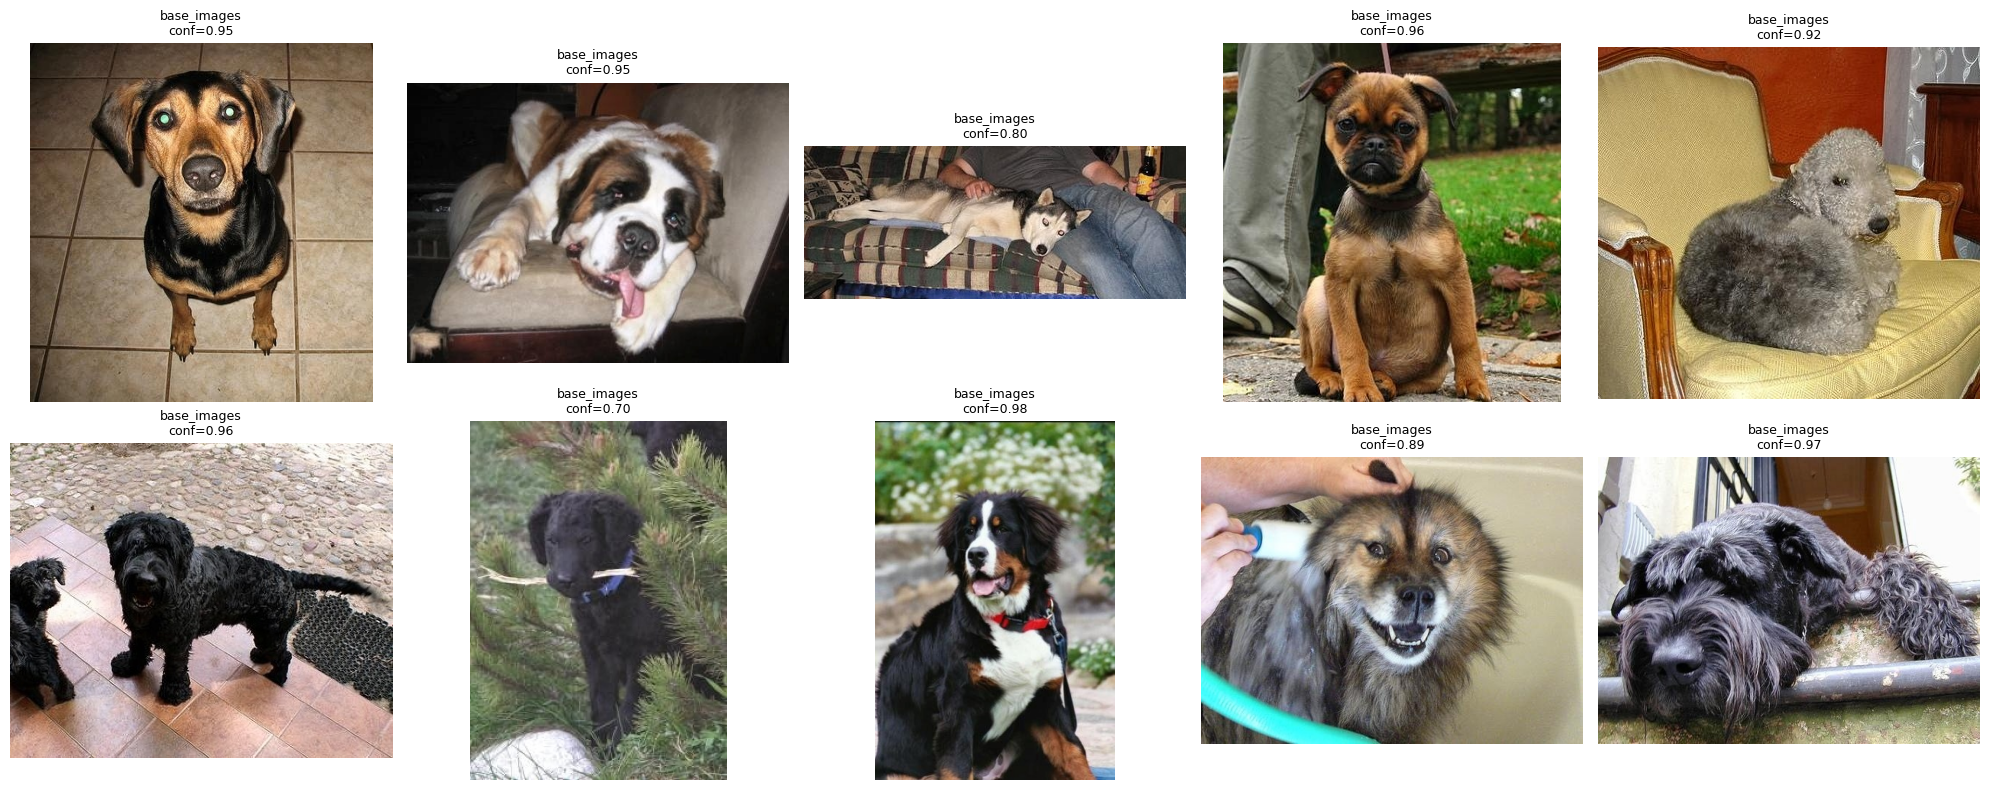

Muestra guardada en: /content/drive/MyDrive/proyecto_integrador_v2/reports/figures/step02b_detection_crop_samples_optimized.png


In [16]:
# 13. Visualización de muestras de crops optimizados

def show_crop_samples(df, n=10):
    ok_crops_df = df[df["crop_status"] == "ok"].copy()

    if len(ok_crops_df) == 0:
        print("No hay crops para mostrar.")
        return

    sample_df = ok_crops_df.sample(min(n, len(ok_crops_df)), random_state=SEED)

    cols = min(5, len(sample_df))
    rows = math.ceil(len(sample_df) / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        crop_path = row["crop_path"]

        try:
            img = Image.open(crop_path).convert("RGB")
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            title = f"{row['source_type']}\nconf={row['best_confidence']:.2f}"
            plt.title(title, fontsize=9)
            plt.axis("off")
        except Exception as e:
            print("Error mostrando crop:", crop_path, e)

    plt.tight_layout()

    sample_path = FIGURES_PATH / "step02b_detection_crop_samples_optimized.png"
    plt.savefig(sample_path, dpi=150)
    plt.show()

    print("Muestra guardada en:", sample_path)


show_crop_samples(detection_df, n=10)

In [17]:
# 14. Casos no detectados para revisión

not_detected_df = detection_df[detection_df["crop_status"] == "no_dog_detected"].copy()

NOT_DETECTED_PATH = TABLES_PATH / "step02b_no_dog_detected_review_optimized.csv"
not_detected_df.to_csv(NOT_DETECTED_PATH, index=False)

print("Casos no detectados:", len(not_detected_df))
print("Guardado en:", NOT_DETECTED_PATH)

display(not_detected_df[["source_type", "quality_label", "original_detection_input_path", "detection_input_path"]].head(20))

Casos no detectados: 1012
Guardado en: /content/drive/MyDrive/proyecto_integrador_v2/reports/tables/step02b_no_dog_detected_review_optimized.csv


,source_type,quality_label,original_detection_input_path,detection_input_path
8,base_images,acceptable,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...
37,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...
54,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...
153,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...
165,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...
217,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...
242,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...
245,base_images,acceptable,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...
315,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...
400,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/proyecto_integrador_v2/images_curated...


# Análisis del Paso 02B

Este notebook genera los crops optimizados del pipeline usando:

```python
CONF_THRESHOLD = 0.15
CROP_MARGIN = 0.35
```

La configuración se seleccionó porque en el Paso 06 mejoró la re-identificación:

- aumentó el número de crops válidos,
- redujo imágenes sin detección,
- mejoró Top-5 Same Dog Accuracy,
- redujo falsos negativos.

El resultado de este notebook será la nueva fuente de crops para regenerar embeddings en el Paso 03.